# X-ray Image Classification

In [122]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [123]:
# setting the training data directory
DataDir = r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\train"

In [124]:
# intiallizing the category of classification
CATEGORIES = ["NORMAL", "PNEUMONIA"]

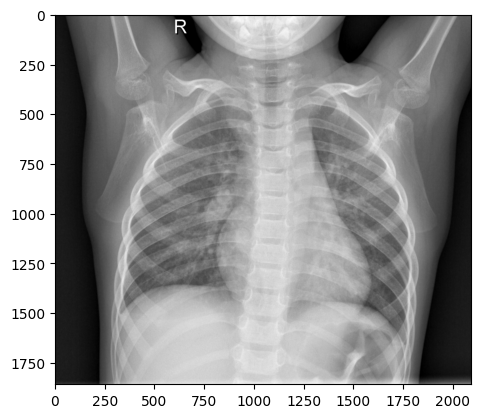

In [125]:
# converting the images into grayscale
for i in CATEGORIES:
    path=os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break

In [126]:
# intializing the size of the image so that every image should be in same dimension
img_size=100

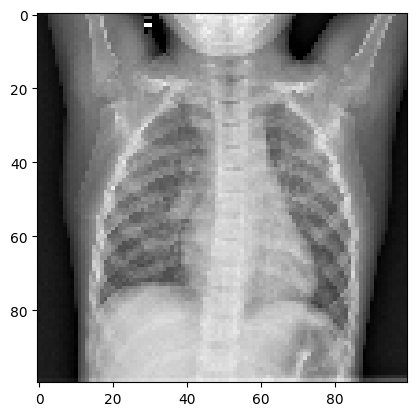

In [127]:
# image after resize and gray scale
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [128]:
training_data=[]

In [129]:
# defining the function for training data according to the categories converting the images into gray scale with resizing the image into 100 x 100
# converting it into numpy arrays
def create_training_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_data.append([new_array,class_num])

            except Exception as e:
                pass

In [130]:
create_training_data()

In [131]:
print(len(training_data))

5226


In [132]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
    print(sample)

[array([[11, 11, 10, ..., 19, 22, 27],
       [10, 10,  7, ..., 23, 24, 28],
       [10,  8,  5, ..., 24, 24, 25],
       ...,
       [17, 17, 16, ..., 18, 20, 20],
       [17, 17, 16, ..., 20, 20, 20],
       [17, 17, 16, ..., 19, 20, 20]], shape=(100, 100), dtype=uint8), 1]
[array([[ 68,  69,  69, ..., 170, 174, 178],
       [ 63,  70,  65, ..., 172, 172, 176],
       [ 55,  57,  58, ..., 169, 164, 182],
       ...,
       [ 88, 104, 116, ...,   3,   2,   2],
       [ 91, 102, 117, ...,   3,   2,   1],
       [ 92, 106, 125, ...,   3,   1,   1]], shape=(100, 100), dtype=uint8), 1]
[array([[27, 18,  9, ..., 46, 36, 31],
       [25, 58,  8, ..., 48, 42, 37],
       [24,  9,  6, ..., 47, 44, 40],
       ...,
       [20, 20, 20, ..., 21, 21, 21],
       [20, 20, 21, ..., 22, 21, 21],
       [21, 21, 21, ..., 21, 21, 21]], shape=(100, 100), dtype=uint8), 1]
[array([[58, 62, 62, ..., 35, 32, 24],
       [60, 60, 63, ..., 36, 30, 25],
       [59, 59, 60, ..., 36, 30, 25],
       ...,
      

In [133]:
X=[]
y=[]

In [134]:
# spliting the features and labels
for features,label in training_data:
    X.append(features)
    y.append(label)

In [135]:
print(X[0].reshape(-1,img_size,img_size,1))

[[[[11]
   [11]
   [10]
   ...
   [19]
   [22]
   [27]]

  [[10]
   [10]
   [ 7]
   ...
   [23]
   [24]
   [28]]

  [[10]
   [ 8]
   [ 5]
   ...
   [24]
   [24]
   [25]]

  ...

  [[17]
   [17]
   [16]
   ...
   [18]
   [20]
   [20]]

  [[17]
   [17]
   [16]
   ...
   [20]
   [20]
   [20]]

  [[17]
   [17]
   [16]
   ...
   [19]
   [20]
   [20]]]]


In [136]:
y = np.array(y)

In [137]:
# reshapping the features for making it compatible with tensorflow
X = np.array(X).reshape(-1,img_size,img_size,1)

In [138]:
# as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\val"

In [139]:
def create_validating_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir_val,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                validation_data.append([new_array,class_num])

            except Exception as e:
                pass

In [140]:
create_validating_data()
print(len(validation_data))

16


In [141]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
    print(sample)

[array([[ 2, 17, 31, ..., 95, 86, 68],
       [ 6, 14, 25, ..., 94, 68, 62],
       [ 2, 10, 23, ..., 88, 73, 60],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(100, 100), dtype=uint8), 0]
[array([[17, 19, 26, ..., 27, 15, 17],
       [18, 23, 33, ..., 53, 43, 22],
       [19, 27, 32, ..., 51, 35, 28],
       ...,
       [ 6,  4,  5, ...,  0,  2,  3],
       [ 6,  4,  5, ...,  0,  2,  3],
       [ 5,  6,  3, ...,  0,  2,  0]], shape=(100, 100), dtype=uint8), 1]
[array([[  0,  85, 102, ...,  95,  73,  51],
       [ 50,  77,  90, ...,  83,  60,  39],
       [ 44,  62,  95, ...,  76,  55,  34],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(100, 100), dtype=uint8), 0]
[array([[  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],


In [142]:
X_val=[]
y_val=[]

In [143]:
for features,label in validation_data:
    X_val.append(features)
    y_val.append(label)

In [144]:
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1,img_size,img_size,1)

In [145]:
# importing the library for training the model and adding the neural network layers
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten, Conv2D,MaxPooling2D
import pickle

In [146]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white....
# In order to scale it down to a scale of 0 to 1, we are performing this step
X = X/255.0
x_val = X_val/255.0

In [147]:
X.shape

(5226, 100, 100, 1)

In [148]:
x_val.shape

(16, 100, 100, 1)

In [149]:
# intializing the neural network layer for training the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation

model = Sequential()

model.add(Input(shape=X.shape[1:]))

model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(256, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [150]:
# summary of the model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 98, 98, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 98, 98, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 47, 47, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 47, 47, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 21, 21, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 21, 21, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 25600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 64)                  │       1,638,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [151]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [152]:
# fittting the model with 10 epochs and using the validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val, y_val))

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 105s 79ms/step - accuracy: 0.9007 - loss: 0.2519 - val_accuracy: 0.9375 - val_loss: 0.2647
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 140s 77ms/step - accuracy: 0.9483 - loss: 0.1417 - val_accuracy: 0.9375 - val_loss: 0.1605
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 93s 71ms/step - accuracy: 0.9594 - loss: 0.1141 - val_accuracy: 1.0000 - val_loss: 0.0742
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 145s 74ms/step - accuracy: 0.9663 - loss: 0.1005 - val_accuracy: 0.8750 - val_loss: 0.3035
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 147s 78ms/step - accuracy: 0.9652 - loss: 0.0929 - val_accuracy: 0.8750 - val_loss: 0.1965
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 145s 80ms/step - accuracy: 0.9677 - loss: 0.0854 - val_accuracy: 0.9375 - val_loss: 0.2006
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 106s 81ms/step - accuracy: 0.9721 - loss: 0.0788 - val_accuracy: 0.9375 - val_loss: 0.1131
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 141s 80ms/step - accuracy: 0

In [153]:
# saving the model
model.save(r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Models\model_10.keras")

In [154]:
# importing the library for testing the model
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model

In [155]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [156]:
# function for preparing the image for predicting the class
def prepare(image):
    img_size=100
    #img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
    new_array=tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1,img_size,img_size,1)

In [157]:
model = tf.keras.models.load_model(r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Models\model_10.keras")

In [158]:
image = r'D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\test\NORMAL\IM-0059-0001.jpeg'

In [159]:
prediction = model.predict(prepare(image) / 255.0)
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
[[0.00107959]]
0
NORMAL


In [160]:
image2 = r'D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\test\PNEUMONIA\person1_virus_6.jpeg'


In [161]:
prediction=model.predict(prepare(image2)/255.0)
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[0.99999934]]
1
PNEUMONIA


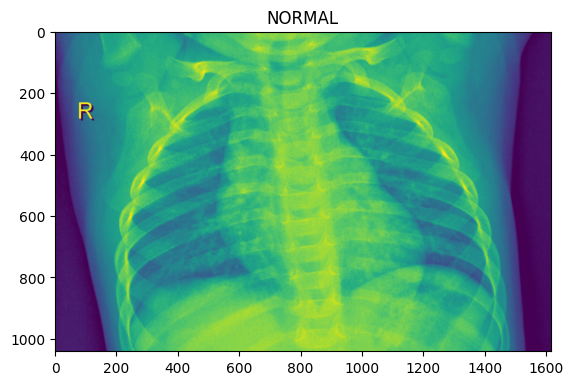

In [162]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

In [163]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for test data
test_dir = r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\test"

# define categories
CATEGORIES = ["NORMAL", "PNEUMONIA"]

# set image size
img_size = 100

# load the saved model
model = load_model(r'D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Models\model_10.keras')

# initialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
    path = os.path.join(test_dir, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (img_size, img_size))
            X_test.append(new_array)
            y_test.append(class_num)
        except Exception as e:
            pass

# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

# print test accuracy
print('Test accuracy:', test_acc)


20/20 - 3s - 139ms/step - accuracy: 0.8221 - loss: 0.9295
Test accuracy: 0.8221153616905212


## Pre-Trained Models

In [164]:
# import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# define image size
img_size = 100

# load the pre-trained model (VGG16)
base_model = VGG16(input_shape=(img_size,img_size,3), include_top=False, weights='imagenet')

# freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# add custom layers for classification
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# create a new model
model = Model(inputs=base_model.input, outputs=predictions)

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# define the image generators for training and validation data
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# specify the training and validation data directories
train_dir = r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\train"
val_dir = r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\val"

# create the image generators for training and validation data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')

# train the model
model.fit(train_generator, epochs=10, validation_data=val_generator)

# evaluate the model on test data
test_dir = r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\test"
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

Found 5226 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9078 - loss: 0.2174 - val_accuracy: 0.8125 - val_loss: 0.3278
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9439 - loss: 0.1502 - val_accuracy: 0.8750 - val_loss: 0.2771
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9460 - loss: 0.1397 - val_accuracy: 0.9375 - val_loss: 0.2177
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9506 - loss: 0.1288 - val_accuracy: 0.9375 - val_loss: 0.2287
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9464 - loss: 0.1400 - val_accuracy: 0.9375 - val_loss: 0.1742
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9566 - loss: 0.1214 - val_accuracy: 0.7500 - val_loss: 0.3233
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9577 - loss: 0.1118 - val_accuracy: 0.7500 - val_loss: 0.3492
Epoch 8/10
164/

In [165]:
# saving the pre-trained model
model.save(r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Models\custom_pre_trained_model_10.keras")

In [166]:
model = tf.keras.models.load_model(r"D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Models\custom_pre_trained_model_10.keras")

In [167]:
model.summary()

Model: "functional_214"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 100, 100, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 100, 100, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 50, 50, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 50, 50, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 25, 25, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 25, 25, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 12, 12, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 18,378,053 (70.11 MB)

 Trainable params: 1,221,121 (4.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2,442,244 (9.32 MB)

In [168]:
# evaluate the model on test data
test_dir = r'D:\data backup 4-7-24\Desktop\Sami\Python Work\Pneumonia Detection\Dataset\test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 974ms/step - accuracy: 0.9167 - loss: 0.2228
Test accuracy: 0.9166666865348816
